In [14]:
import os, re, glob
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
BASE = "/mnt/data/weatherloss/WindPower/data/BOZ_Turbines"
COORD_DIR = os.path.join(BASE, "coordinates")
ENTSOE_CSV = os.path.join(BASE, "windpowerdata", "BE_offshore_per_unit_3H_meanMW_2023-01_to_2025-07.csv")
CERRA_ZARR = "/mnt/data/weatherloss/WindPower/data/Cerra_boz.zarr"  

In [8]:
ds = xr.open_zarr(CERRA_ZARR, consolidated=True)

lon2d = np.asarray(ds["longitude"])
lat2d = np.asarray(ds["latitude"])

ny, nx = ds.sizes["y"], ds.sizes["x"]

pts = np.c_[lon2d.ravel(), lat2d.ravel()]
tree = cKDTree(pts)

print(f"Grid size: ny={ny}, nx={nx}; KDTree ready with {pts.shape[0]} points.")

Grid size: ny=157, nx=211; KDTree ready with 33127 points.


In [101]:
_HUB_REGEX = re.compile(
    r"(?:^|\b)(?:OSS|OHVS|SUB-?STATION|OFFSHORE\s+HIGH\s+VOLTAGE|HUB|PLATFORM)(?:\b|$)",
    re.I,
)

def load_all_turbines(coord_dir):
    rows = []
    for csv in glob.glob(os.path.join(coord_dir, "*_turbines_coords.csv")):
        farm = os.path.basename(csv).replace("_turbines_coords.csv", "")
        df = pd.read_csv(csv)

        # find columns robustly
        cols = {c.lower().strip(): c for c in df.columns}
        name_col = cols.get("name", next((c for c in df.columns if c.lower().startswith("name")), None))
        lon_col  = cols.get("longitude", next((c for c in df.columns if "lon" in c.lower()), None))
        lat_col  = cols.get("latitude", next((c for c in df.columns if "lat" in c.lower()), None))
        if not (name_col and lon_col and lat_col):
            raise ValueError(f"Missing columns in {csv}. Found: {list(df.columns)}")

        sub = df[[name_col, lon_col, lat_col]].copy()
        sub.columns = ["name","lon","lat"]

        # drop hubs/platforms
        sub = sub[~sub["name"].astype(str).str.contains(_HUB_REGEX)]

        sub["farm"] = farm
        rows.append(sub)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["name","lon","lat","farm"])

turbines = load_all_turbines(COORD_DIR)

# Split rule for CPower:
# SW has 30 turbines: A1-A7, B1-B7, C1-C7, D0-D8
# NE has 24 turbines: E*, F*, G*, H*, I*, J* and any D>=9
_LETTER_NUM = re.compile(r"^\s*([A-J])\s*-?\s*(\d+)\s*$", re.I)

def cpower_subfarm(name: str) -> str:
    m = _LETTER_NUM.match(str(name).strip())
    if not m:
        return "CPower_unknown"
    letter = m.group(1).upper()
    n = int(m.group(2))
    if letter in {"A","B","C"}:
        return "CPower_SW"
    if letter == "D":
        return "CPower_SW" if 0 <= n <= 8 else "CPower_NE"
    if letter in {"E","F","G","H","I","J"}:
        return "CPower_NE"
    return "CPower_unknown"

turbines["farm_split"] = turbines["farm"]
mask_cp = turbines["farm"].str.fullmatch("CPower", case=False, na=False)
turbines.loc[mask_cp, "farm_split"] = turbines.loc[mask_cp, "name"].map(cpower_subfarm)

# Quick sanity checks
print("All farms (after split):", sorted(turbines["farm_split"].unique()))
print("Counts per farm:")
print(turbines.groupby("farm_split").size().sort_values(ascending=False))
print("Any unknown CPower labels?",
      (turbines["farm_split"]=="CPower_unknown").sum())


All farms (after split): ['Belwind', 'CPower_NE', 'CPower_SW', 'CPower_unknown', 'Mermaid', 'Nobelwind', 'Norther', 'Northwester2', 'Northwind', 'Rentel', 'Seastar']
Counts per farm:
farm_split
Northwind         73
Belwind           56
Nobelwind         51
Norther           44
Rentel            42
Seastar           30
CPower_SW         30
Mermaid           28
CPower_NE         24
Northwester2      23
CPower_unknown     1
dtype: int64
Any unknown CPower labels? 1


In [19]:
# drop unknown CPower labels (rare)
turbines_use = turbines[turbines["farm_split"] != "CPower_unknown"].copy()

# compute centroids per farm (using the split label)
farm_key = "farm_split"
centroids = (turbines_use.groupby(farm_key)[["lon","lat"]]
             .mean()
             .rename(columns={"lon":"farm_lon","lat":"farm_lat"}))

# 2) nearest grid cell to each centroid
dist, idx = tree.query(centroids[["farm_lon","farm_lat"]].values, k=1)
j = (idx % nx).astype(int)
i = (idx // nx).astype(int)

# 3) assemble a tidy table
farm_cells = centroids.copy()
farm_cells["y"] = i
farm_cells["x"] = j
farm_cells["lon_cell"] = lon2d[i, j]
farm_cells["lat_cell"] = lat2d[i, j]
farm_cells["deg_error"] = np.hypot(farm_cells["lon_cell"]-farm_cells["farm_lon"],
                                   farm_cells["lat_cell"]-farm_cells["farm_lat"])
farm_cells = farm_cells.reset_index()  # keep farm name as a column
farm_cells = farm_cells.rename(columns={farm_key: "farm"})

FARM_CELLS_CSV = os.path.join(BASE, "coordinates", "farm_to_cell_lookup.csv")
farm_cells.to_csv(FARM_CELLS_CSV, index=False)

In [25]:
farm_cells

,farm,farm_lon,farm_lat,y,x,lon_cell,lat_cell,deg_error
0,Belwind,2.802245,51.669541,56,119,2.814370,51.668860,0.012144
1,CPower_NE,2.985691,51.563432,54,121,2.984126,51.576947,0.013605
2,CPower_SW,2.921944,51.539986,53,120,2.910163,51.524279,0.019635
3,Mermaid,2.737938,51.717412,57,118,2.729240,51.714726,0.009103
4,Nobelwind,2.821048,51.661386,56,119,2.814370,51.668860,0.010022
5,Norther,3.012421,51.525958,53,121,2.989452,51.527615,0.023029
6,Northwester2,2.753184,51.686778,56,118,2.734853,51.665409,0.028154
7,Northwind,2.902710,51.620029,55,120,2.899332,51.622934,0.004455
8,Rentel,2.944992,51.591059,54,121,2.984126,51.576947,0.041601
9,Seastar,2.861933,51.633703,55,120,2.899332,51.622934,0.038919


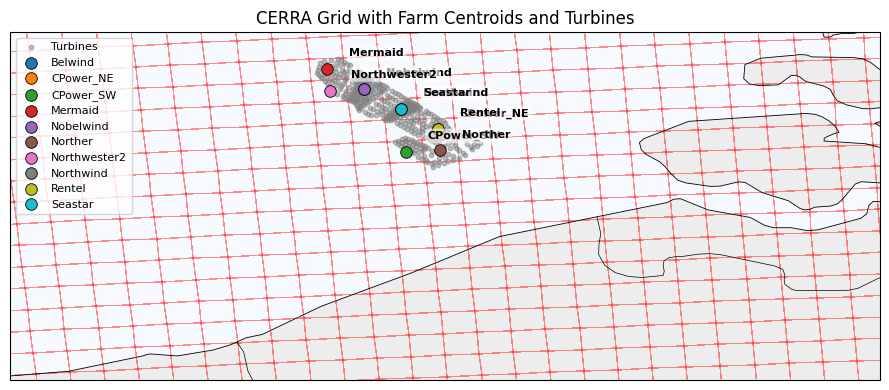

In [24]:
def add_cerra_cells(ax, ds, linewidth=0.3, color="red", alpha=0.25):
    """Overlay CERRA grid lines."""
    lon2d = ds["longitude"].values
    lat2d = ds["latitude"].values
    qm = ax.pcolormesh(
        lon2d, lat2d, np.zeros_like(lon2d),
        shading="nearest", transform=ccrs.PlateCarree(),
        edgecolors=color, alpha=alpha, linewidth=linewidth
    )
    qm.set_facecolor("none")
    return qm

# --- actual plotting ---
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent((2,4, 51, 51.8), crs=ccrs.PlateCarree())

# coastlines and borders
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", alpha=0.6)

# add the cerra grid
add_cerra_cells(ax, ds, linewidth=0.3, color="red")

# all turbine coordinates (small dots)
ax.scatter(
    turbines["lon"], turbines["lat"],
    s=10, color="gray", alpha=0.5,
    transform=ccrs.PlateCarree(), label="Turbines"
)

# farm centroids (large colored points)
farms = farm_cells["farm"].unique()
cmap = plt.get_cmap("tab10")
colors = {f: cmap(i % 10) for i, f in enumerate(farms)}

for f in farms:
    row = farm_cells.loc[farm_cells["farm"] == f].iloc[0]
    ax.scatter(
        row["lon_cell"], row["lat_cell"],
        s=70, marker="o", edgecolors="black",
        facecolors=colors[f], linewidths=0.6,
        transform=ccrs.PlateCarree(), label=f
    )
    ax.text(
        row["lon_cell"] + 0.05, row["lat_cell"] + 0.03,
        f, fontsize=8, fontweight="bold",
        transform=ccrs.PlateCarree(),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

ax.legend(fontsize=8, loc="upper left", frameon=True)
ax.set_title("CERRA Grid with Farm Centroids and Turbines", fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
ds=xr.open_dataset("/mnt/data/weatherloss/WindPower/data/Cerra_boz.nc")
CSV_TO_FARM = {
    "Belwind Phase 1":               "Belwind",
    "Mermaid Offshore WP":           "Mermaid",
    "Nobelwind Offshore Windpark":   "Nobelwind",
    "Norther Offshore WP":           "Norther",
    "Northwester 2":                 "Northwester2",
    "Northwind":                     "Northwind",
    "Rentel Offshore WP":            "Rentel",
    "Seastar Offshore WP":           "Seastar",
    "Thorntonbank - C-Power - Area NE": "CPower_NE",
    "Thorntonbank - C-Power - Area SW": "CPower_SW",
}

# 2) Load the CSV 
dfp_raw = pd.read_csv(ENTSOE_CSV)
# parse time to UTC
time_col = next(c for c in dfp_raw.columns if c.lower().startswith("time"))
dfp_raw[time_col] = pd.to_datetime(dfp_raw[time_col], utc=True, errors="coerce")
dfp_raw = dfp_raw.dropna(subset=[time_col]).sort_values(time_col)

# 3) Rename columns to our farm labels and keep only those present in the mapping
keep_cols = [c for c in dfp_raw.columns if c in CSV_TO_FARM]  # only mapped farm columns
dfp = (dfp_raw[[time_col] + keep_cols]
       .rename(columns={**{time_col:"time"}, **CSV_TO_FARM})
       .set_index("time")
       .sort_index())

# 4) Align to CERRA time coordinate (3-hourly)
cerra_times = pd.DatetimeIndex(pd.to_datetime(ds["time"].values)).tz_localize("UTC")
dfp_aligned = dfp.reindex(cerra_times)

# 5) Keep only farms we have a cell for
farms_with_cells = set(farm_cells["farm"].tolist())
farms_in_csv = set(dfp_aligned.columns)
farms = sorted(farms_with_cells & farms_in_csv)

dfp_aligned = dfp_aligned[farms].astype("float32")

print("Farms after intersection:", farms)
print("ENTSO-E aligned shape:", dfp_aligned.shape,
      "time span:", dfp_aligned.index.min(), "→", dfp_aligned.index.max())

# 6) Build one-hot masks per farm: mask[farm,y,x] == 1 at the assigned cell, else 0
ny, nx = ds.sizes["y"], ds.sizes["x"]
mask_arr = np.zeros((len(farms), ny, nx), dtype="float32")

lookup = {row["farm"]: (int(row["y"]), int(row["x"])) for _, row in farm_cells.iterrows()}
for k, f in enumerate(farms):
    i, j = lookup[f]
    mask_arr[k, i, j] = 1.0

farm_mask = xr.DataArray(
    mask_arr,
    coords={"farm": farms, "y": ds["y"], "x": ds["x"]},
    dims=("farm","y","x"),
    name="farm_mask_onehot",
)
farm_mask

Farms after intersection: ['Belwind', 'CPower_NE', 'CPower_SW', 'Mermaid', 'Nobelwind', 'Norther', 'Northwester2', 'Northwind', 'Rentel', 'Seastar']
ENTSO-E aligned shape: (7544, 10) time span: 2023-01-01 00:00:00+00:00 → 2025-07-31 21:00:00+00:00


<xarray.DataArray 'farm_mask_onehot' (farm: 10, y: 157, x: 211)> Size: 1MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * farm     (farm) <U12 480B 'Belwind' 'CPower_NE' ... 'Rentel' 'Seastar'
  * y        (y) int64 1kB 0 1 2 3 4 5 6 7 8 ... 149 150 151 152 153 154 155 156
  * x        (x) int64 2kB 0 1 2 3 4 5 6 7 8 ... 203 204 205 206 207 208 209 210

Preview time: 2023-01-13 12:00:00+00:00
Belwind         156.000000
CPower_NE       143.666672
CPower_SW       170.000000
Mermaid         213.333328
Nobelwind       163.000000
Norther         348.666656
Northwester2    185.333328
Northwind       205.666672
Rentel          296.000000
Seastar         235.000000

⚠️ Farms sharing a grid cell:
        farm   y    x
1  CPower_NE  54  121
8     Rentel  54  121
7  Northwind  55  120
9    Seastar  55  120
0    Belwind  56  119
4  Nobelwind  56  119
Sum(series) = 2116.66650390625  | Sum(power_map) = 2116.66650390625


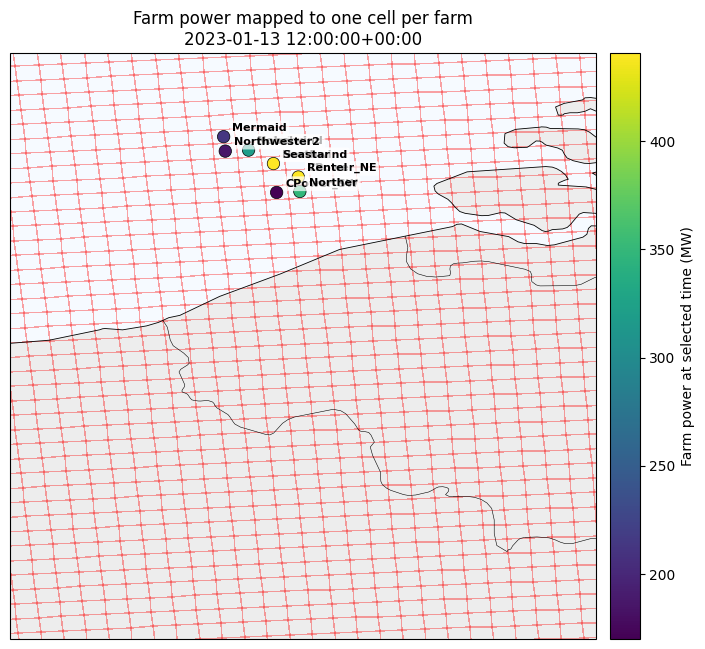

In [46]:
# 1) pick a timestamp that exists in dfp_aligned
t_pick = dfp_aligned.index[100]  # choose any row, or set explicitly
series = dfp_aligned.loc[t_pick]           # pandas Series: power per farm (MW)
print("Preview time:", t_pick)
print(series.to_string())

# 2) build a 2D power map — accumulate farms sharing a grid cell
power_map = np.zeros((ds.sizes["y"], ds.sizes["x"]), dtype="float32")

dups = farm_cells.duplicated(subset=["y", "x"], keep=False)
if dups.any():
    print("\n Farms sharing a grid cell:")
    print(farm_cells.loc[dups, ["farm", "y", "x"]].sort_values(["y", "x"]))

for f, val in series.items():
    i, j = lookup[f]
    if np.isfinite(val):
        power_map[i, j] += float(val) 

# 3) numeric sanity: sum of map vs sum of series
print("Sum(series) =", float(series.fillna(0).sum()),
      " | Sum(power_map) =", float(power_map.sum()))

# 4) plot in a zoomed extent
extent = (2.0, 4.0, 50.0, 52.0)
lon2d = ds["longitude"].values
lat2d = ds["latitude"].values

fig, ax = plt.subplots(figsize=(7.5, 6.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent(extent, crs=ccrs.PlateCarree())

# background
ax.coastlines(resolution="10m", linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.4)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", alpha=0.6)

# grid overlay
qm = ax.pcolormesh(
    lon2d, lat2d, np.zeros_like(lon2d),
    shading="nearest", transform=ccrs.PlateCarree(),
    edgecolors="red", alpha=0.2, linewidth=0.3
)
qm.set_facecolor("none")

# power dots (colored by magnitude)
# we’ll only plot cells where power_map > 0
ii, jj = np.where(power_map > 0)
vals = power_map[ii, jj]
sc = ax.scatter(
    lon2d[ii, jj], lat2d[ii, jj],
    c=vals, s=80, cmap="viridis", edgecolors="k", linewidths=0.5,
    transform=ccrs.PlateCarree()
)
cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
cb.set_label("Farm power at selected time (MW)")

# optional: add farm labels
for f in series.index:
    i, j = lookup[f]
    ax.text(
        lon2d[i, j] + 0.03, lat2d[i, j] + 0.02, f,
        fontsize=8, fontweight="bold", transform=ccrs.PlateCarree(),
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

ax.set_title(f"Farm power mapped to one cell per farm\n{t_pick}")
plt.tight_layout()
plt.show()



In [48]:
P_farm = xr.DataArray(
    dfp_aligned.fillna(0.0).to_numpy(dtype="float32"),
    coords={"time": dfp_aligned.index, "farm": dfp_aligned.columns.tolist()},
    dims=("time", "farm"),
    name="farm_power_series_MW",
)

# 2) Subset the one-hot mask to the same farm order
farm_mask_sub = farm_mask.sel(farm=P_farm.coords["farm"])

# 3) Scatter & sum with a lambda-wrapped einsum 
power_cell_total = xr.apply_ufunc(
    lambda P, M: np.einsum("tf,fij->tij", P, M),
    P_farm, farm_mask_sub,
    input_core_dims=[["time","farm"], ["farm","y","x"]],
    output_core_dims=[["time","y","x"]],
    vectorize=False,
    dask="parallelized",
    output_dtypes=[np.float32],
)

power_cell_total = power_cell_total.assign_coords(
    time=P_farm.time, y=ds["y"], x=ds["x"]
).rename("power_cell_total")

power_cell_total.attrs.update({
    "long_name": "Offshore wind power mapped to CERRA grid (sum across farms)",
    "units": "MW",
    "note": "One-cell-per-farm mapping; co-located farms summed."
})

# Sanity checks
def check_time(ti):
    s = float(P_farm.isel(time=ti).sum().item())
    g = float(power_cell_total.isel(time=ti).sum().item())
    print(f"t[{ti}] {str(P_farm.time.values[ti])}: series_sum={s:.3f} MW | grid_sum={g:.3f} MW")

for ti in [0, 100, 500, len(P_farm.time)-1]:
    check_time(ti)

power_cell_total


t[0] 1672531200000000000: series_sum=1961.333 MW | grid_sum=1961.333 MW
t[100] 1673611200000000000: series_sum=2116.667 MW | grid_sum=2116.667 MW
t[500] 1677931200000000000: series_sum=368.667 MW | grid_sum=368.667 MW
t[7543] 1753995600000000000: series_sum=0.000 MW | grid_sum=0.000 MW


<xarray.DataArray 'power_cell_total' (time: 7544, y: 157, x: 211)> Size: 1000MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * time        (time) datetime64[ns, UTC] 60kB 2023-01-01 00:00:00+00:00 ......
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
    valid_time  datetime64[ns] 8B 2020-01-01
  * y           (y) int64 1kB 0 1 2 3 4 5 6 7 ... 150 151 152 153 154 155 156
  * x           (x) int64 2kB 0 1 2 3 4 5 6 7 ... 204 205 206 207 208 209 210
Attributes:
    long_name:  Offshore wind power mapped to CERRA grid (sum across farms)
    units:      MW
    note:       One-cell-per-farm mapping; co-located farms summed.

In [92]:
ny, nx = ds.sizes["y"], ds.sizes["x"]

# 1) Ensure power_cell_total has naive UTC time (no tz)
t_idx = power_cell_total.indexes["time"]  # pandas DatetimeIndex
if t_idx.tz is not None:
    t_naive = t_idx.tz_convert("UTC").tz_localize(None)
else:
    # Already naive; assume it's UTC-aligned
    t_naive = t_idx  # or t_idx.tz_localize(None) if you prefer explicit

power_cell_total = power_cell_total.assign_coords(time=t_naive)

farm_mask_to_write = (farm_mask.sum(dim="farm") > 0).astype("float32")
farm_mask_to_write = farm_mask_to_write.rename("mask")


# 3) Assemble dataset with consistent coords/dtypes
power_ds = xr.Dataset(
    data_vars={
        "power": power_cell_total.astype("float32"),
        "mask": farm_mask_to_write,
    }
)

# Helpful attrs
power_ds["power"].attrs.update({
    "long_name": "Offshore wind power mapped to CERRA grid (sum across farms)",
    "units": "MW",
    "source": "ENTSO-E per-farm 3H means mapped to 1 grid cell per farm; co-located farms summed",
    "note": "Belgian offshore; CPower split NE/SW; time is UTC (naive).",
})
power_ds["mask"].attrs.update({
    "long_name": "Mask of farm locations on CERRA grid (2D)",
    "values": "1 at any farm cell, else 0",
})

# 4) Chunking & write (append)
encoding = {
    "power": {"chunks": (24, ny, nx)},
    "mask": {"chunks": (ny, nx)},
}

In [94]:
ZARR_PATH = "/mnt/data/weatherloss/WindPower/data/Cerra_boz.zarr"
power_ds.to_zarr(ZARR_PATH, mode="a", consolidated=True, encoding=encoding)

In [98]:
encoding = {
    'power': {'chunks': (24, 157, 211)}
    # you can add others if you want to pin their chunks too
}

(
    xr.open_zarr("/mnt/data/weatherloss/WindPower/data/Cerra_boz.zarr", consolidated=True)
      # optional: choose in-memory chunks to control how the rewrite proceeds
      .chunk({'time': 24, 'y': 157, 'x': 211})
      .to_zarr("/mnt/data/weatherloss/WindPower/data/Cerra_boz_rechunked.zarr",
               mode="w",
               consolidated=True,
               encoding=encoding)
)
